# Vanilla Policy Gradient with nonlinear basis functions
## A fully actuated double pendulum — no advantage, no baseline, no neural network

This self-contained notebook implements **REINFORCE with reward-to-go** in NumPy. The policy is a Gaussian whose mean is a weighted sum of fixed nonlinear features. Only the weights are learned.

The task is deliberately modest: move a double pendulum from near its hanging configuration to a prescribed posture and hold it there. This is **posture regulation**, not swing-up or the underactuated Acrobot benchmark. Both joints have motors. We use a smooth dense reward, short episodes, and batches of independent trajectories to make learning without a baseline practical.

Run the cells in order in Jupyter or Google Colab. A CPU is sufficient. The final cells show the reward learning curve, angle trajectories, and a side-by-side animation of the initial and learned policies. Learning without a baseline is noisy; one seed is an illustration, not a performance benchmark.

In [ ]:
# Run once if these packages are not installed, then restart the kernel if needed.
# %pip install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

SEED = 7
UPDATES = 3000
BATCH_SIZE = 256
HORIZON = 120
DT = 0.04
GAMMA = 0.97
LEARNING_RATE = 0.03
SIGMA = 0.45                 # Fixed exploration standard deviation in latent action space.
MAX_TORQUE = 12.0            # Nm, at each joint.
TARGET = np.array([3.14, 0.0])  # Absolute link angles from the downward vertical, radians.
train_rng = np.random.default_rng(SEED)


## 1. Double-pendulum dynamics

The state is $s=(q_1,q_2,\dot q_1,\dot q_2)$, with **absolute** link angles measured from the downward vertical. Each mass and link length is one in SI units; links are massless with point masses at their ends. Motor torques $u_1,u_2$ act at the base and elbow. In absolute-angle coordinates their generalized force is $(u_1-u_2,u_2)$.

For $d=q_1-q_2$, the equations are
$$
\begin{bmatrix}2&\cos d\\\cos d&1\end{bmatrix}\ddot q
=\begin{bmatrix}u_1-u_2\\u_2\end{bmatrix}
-\begin{bmatrix}\sin d\,\dot q_2^2\\-\sin d\,\dot q_1^2\end{bmatrix}
-9.81\begin{bmatrix}2\sin q_1\\\sin q_2\end{bmatrix}
-b\dot q.
$$
The last term models viscous drag on each absolute link velocity ($b=0.3$). Four semi-implicit Euler substeps integrate each control interval. No dynamics derivatives are used by the learner.

The per-step reward is
$$r=-\frac{\|\operatorname{wrap}(q-q^*)\|^2+0.03\|\dot q\|^2+0.001\|u\|^2}{T}.$$
Higher (closer to zero) is better. Dividing by the fixed horizon $T$ keeps return magnitudes manageable; this is a fixed reward scale, not a data-dependent normalization or baseline. Episodes have a fixed length and do not terminate early.

In [2]:
def wrap(angle):
    """Map angles to [-pi, pi)."""
    return (angle + np.pi) % (2 * np.pi) - np.pi


def reset(batch_size, rng):
    """Start near the hanging position, with small random velocities."""
    return np.concatenate((rng.normal(0, 0.08, (batch_size, 2)),
                           rng.normal(0, 0.04, (batch_size, 2))), axis=1)


def step(state, torque):
    """Vectorized physical simulation: one row per independent pendulum."""
    q = state[:, :2].copy()
    velocity = state[:, 2:].copy()
    h = DT / 4
    for _ in range(4):
        difference = q[:, 0] - q[:, 1]
        sine, cosine = np.sin(difference), np.cos(difference)
        rhs1 = (torque[:, 0] - torque[:, 1] - sine * velocity[:, 1]**2
                - 2 * 9.81 * np.sin(q[:, 0]) - 0.3 * velocity[:, 0])
        rhs2 = (torque[:, 1] + sine * velocity[:, 0]**2
                - 9.81 * np.sin(q[:, 1]) - 0.3 * velocity[:, 1])
        determinant = 2 - cosine**2  # Always >= 1: the mass matrix is nonsingular.
        acceleration = np.column_stack(((rhs1 - cosine * rhs2) / determinant,
                                         (2 * rhs2 - cosine * rhs1) / determinant))
        velocity += h * acceleration
        q = wrap(q + h * velocity)
    next_state = np.column_stack((q, velocity))
    error = wrap(q - TARGET)
    cost = (np.sum(error**2, axis=1) + 0.03 * np.sum(velocity**2, axis=1)
            + 0.001 * np.sum(torque**2, axis=1))
    return next_state, -cost / HORIZON


## 2. Policy: a linear combination of nonlinear bases

The feature vector contains a constant, sines and cosines of angle errors, bounded velocities, and cross-link trigonometric terms. These are fixed functions, not trainable hidden layers. With 11 features and two motors, the policy has **22 trainable parameters**:
$$\mu_W(s)=\phi(s)^T W,\qquad z\sim\mathcal N(\mu_W(s),\sigma^2 I),\qquad u=u_{\max}\tanh(z).$$

The squashing map bounds the motor torque smoothly. We store the sampled **latent** action $z$ and compute its Gaussian score:
$$\nabla_W\log p_W(z\mid s)=\phi(s)\frac{(z-\mu_W(s))^T}{\sigma^2}.$$
The tanh change-of-variables Jacobian does not depend on $W$ when the sampled action is held fixed, so this is also the correct score for the squashed action. We do not differentiate through the sampled action or the simulator.

In [3]:
def features(state):
    """Fixed, bounded nonlinear basis functions; no neural network."""
    e = wrap(state[:, :2] - TARGET)
    v = np.tanh(state[:, 2:] / 3.0)
    return np.column_stack((np.ones(len(state)),
                            np.sin(e), np.cos(e), v,
                            np.sin(e[:, 0] - e[:, 1]),
                            np.cos(e[:, 0] - e[:, 1]),
                            np.sin(e[:, 0] + e[:, 1]),
                            np.cos(e[:, 0] + e[:, 1])))


N_FEATURES = features(np.zeros((1, 4))).shape[1]
initial_weights = np.zeros((N_FEATURES, 2))


def rollout(weights, rng, batch_size, stochastic=True):
    """Collect fresh on-policy trajectories with weights frozen throughout."""
    state = reset(batch_size, rng)
    states = np.empty((HORIZON + 1, batch_size, 4))
    rewards = np.empty((HORIZON, batch_size))
    scores = np.empty((HORIZON, batch_size, N_FEATURES, 2))
    states[0] = state
    for t in range(HORIZON):
        phi = features(state)
        mean = phi @ weights
        noise = rng.normal(size=mean.shape) if stochastic else np.zeros_like(mean)
        latent_action = mean + SIGMA * noise
        torque = MAX_TORQUE * np.tanh(latent_action)
        # (z - mean) / sigma^2 = noise / sigma.
        scores[t] = phi[:, :, None] * (noise / SIGMA)[:, None, :]
        state, rewards[t] = step(state, torque)
        states[t + 1] = state
    return states, rewards, scores


## 3. REINFORCE update, without advantage estimates

Our finite-horizon objective is $J(W)=\mathbb E[\sum_{t=0}^{T-1}\gamma^t r_t]$. For each sampled episode, compute the **raw discounted reward-to-go**
$$G_t=r_t+\gamma r_{t+1}+\cdots+\gamma^{T-1-t}r_{T-1}.$$
Then perform plain stochastic gradient **ascent**:
$$\widehat{\nabla_W J}=\frac1B\sum_{i=1}^{B}\sum_{t=0}^{T-1}\gamma^t G_t^{(i)}\nabla_W\log p_W(z_t^{(i)}\mid s_t^{(i)}),\qquad
W\leftarrow W+\alpha\widehat{\nabla_W J}.$$

The outer $\gamma^t$ matches the stated discounted start-state objective. There is no critic, value function, advantage, return centering, standardization, entropy bonus, or gradient clipping. Each batch is discarded after a single update. Batching reduces sampling noise without changing this estimator.

For the derivation, see [OpenAI Spinning Up: reward-to-go policy gradient](https://spinningup.openai.com/en/latest/spinningup/rl_intro3.html). Here we stop at the reward-to-go formulation, before introducing baselines.

In [4]:
def reward_to_go(rewards):
    """Backward Monte Carlo return computation, separately for each episode."""
    returns = np.empty_like(rewards)
    running = np.zeros(rewards.shape[1])
    for t in reversed(range(len(rewards))):
        running = rewards[t] + GAMMA * running
        returns[t] = running
    return returns


def policy_gradient(rewards, scores):
    returns = reward_to_go(rewards)  # Raw returns: do not subtract their mean!
    discount = GAMMA ** np.arange(len(rewards))
    return np.einsum('tb,tbfa,t->fa', returns, scores, discount) / rewards.shape[1]


# Small mathematical checks catch indexing and score-function mistakes.
example = np.array([[1.0], [2.0], [3.0]])
assert np.allclose(reward_to_go(example).ravel(),
                   [1 + GAMMA * 2 + GAMMA**2 * 3, 2 + GAMMA * 3, 3])
assert np.allclose(step(np.zeros((1, 4)), np.zeros((1, 2)))[0], 0)
check_rng = np.random.default_rng(123)
x = reset(1, check_rng)
phi = features(x)[0]
z = np.array([0.2, -0.3])
w = check_rng.normal(0, 0.1, initial_weights.shape)
direction = check_rng.normal(size=w.shape)
def log_probability(w):
    return -0.5 * np.sum(((z - phi @ w) / SIGMA)**2)
eps = 1e-6
finite_difference = (log_probability(w + eps * direction)
                     - log_probability(w - eps * direction)) / (2 * eps)
score = phi[:, None] * ((z - phi @ w) / SIGMA**2)[None, :]
assert np.allclose(finite_difference, np.sum(score * direction), rtol=1e-5)
print(f"Checks passed. Policy parameters: {initial_weights.size}.")


Checks passed. Policy parameters: 22.


In [5]:
# Independent evaluation RNGs keep diagnostics from altering training samples.
# Reusing evaluation seeds gives the policies identical initial states and noise draws.
EVAL_EPISODES = 64
EVAL_EVERY = 10

def evaluate(weights, stochastic):
    _, rewards, _ = rollout(weights, np.random.default_rng(2026),
                            EVAL_EPISODES, stochastic=stochastic)
    return rewards.sum(axis=0).mean()

weights = initial_weights.copy()
train_rng = np.random.default_rng(SEED)  # Rerunning this cell reproduces training.
train_mean, train_std, objective_history = [], [], []
eval_updates = [0]
eval_stochastic = [evaluate(weights, True)]
eval_mean_action = [evaluate(weights, False)]

for update in range(1, UPDATES + 1):
    _, rewards, scores = rollout(weights, train_rng, BATCH_SIZE)
    gradient = policy_gradient(rewards, scores)
    weights += LEARNING_RATE * gradient
    assert np.isfinite(weights).all(), "Nonfinite weights; check simulation and step size."
    episode_rewards = rewards.sum(axis=0)
    train_mean.append(episode_rewards.mean())
    train_std.append(episode_rewards.std())
    objective_history.append(np.mean(np.sum(
        rewards * (GAMMA ** np.arange(HORIZON))[:, None], axis=0)))
    if update % EVAL_EVERY == 0:
        eval_updates.append(update)
        eval_stochastic.append(evaluate(weights, True))
        eval_mean_action.append(evaluate(weights, False))
    if update % 50 == 0:
        print(f"Update {update:3d}/{UPDATES} | "
              f"training reward {train_mean[-1]: .3f} | "
              f"mean-action evaluation {eval_mean_action[-1]: .3f}")

print(f"\nStochastic evaluation: {eval_stochastic[0]:.3f} -> {eval_stochastic[-1]:.3f}")
print(f"Mean-action evaluation: {eval_mean_action[0]:.3f} -> {eval_mean_action[-1]:.3f}")


Update  50/3000 | training reward -0.243 | mean-action evaluation -0.103
Update 100/3000 | training reward -0.211 | mean-action evaluation -0.094
Update 150/3000 | training reward -0.188 | mean-action evaluation -0.093
Update 200/3000 | training reward -0.183 | mean-action evaluation -0.091
Update 250/3000 | training reward -0.177 | mean-action evaluation -0.090
Update 300/3000 | training reward -0.170 | mean-action evaluation -0.092
Update 350/3000 | training reward -0.168 | mean-action evaluation -0.092
Update 400/3000 | training reward -0.167 | mean-action evaluation -0.090
Update 450/3000 | training reward -0.168 | mean-action evaluation -0.092
Update 500/3000 | training reward -0.161 | mean-action evaluation -0.093
Update 550/3000 | training reward -0.161 | mean-action evaluation -0.091
Update 600/3000 | training reward -0.162 | mean-action evaluation -0.089
Update 650/3000 | training reward -0.156 | mean-action evaluation -0.088
Update 700/3000 | training reward -0.157 | mean-act

## 4. Reward over time

The main plot reports **undiscounted episode reward**, summed over the fixed horizon. The shaded band is one standard deviation across training episodes, not a confidence interval across independent training runs. Evaluation uses fixed held-out seeds. “Mean action” sets the latent exploration noise to zero; it is a separate deployment diagnostic, not the stochastic policy optimized during training. The second plot shows the discounted objective used by the gradient estimator.

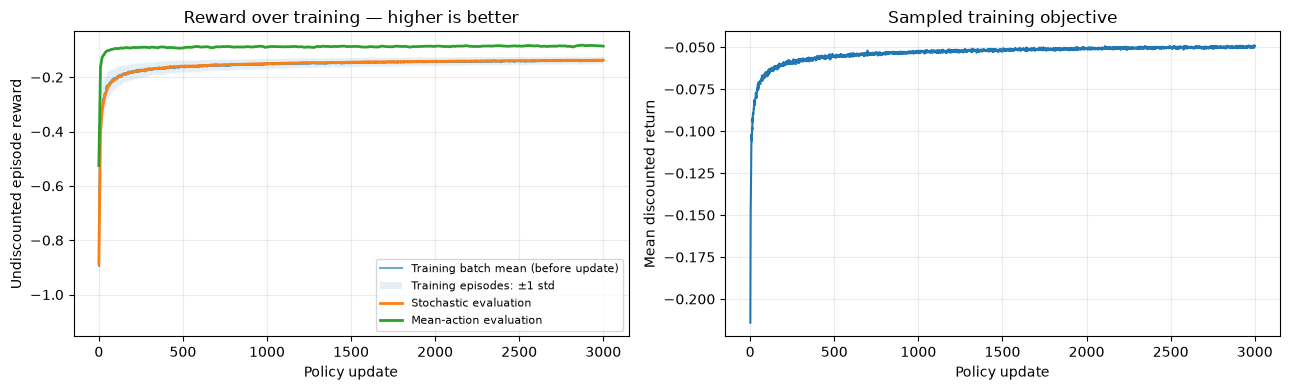

In [6]:
updates = np.arange(1, UPDATES + 1)
mean, std = np.asarray(train_mean), np.asarray(train_std)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(updates, mean, alpha=0.65, label="Training batch mean (before update)")
axes[0].fill_between(updates, mean - std, mean + std, alpha=0.12,
                     label="Training episodes: ±1 std")
axes[0].plot(eval_updates, eval_stochastic, label="Stochastic evaluation", lw=2)
axes[0].plot(eval_updates, eval_mean_action, label="Mean-action evaluation", lw=2)
axes[0].set(xlabel="Policy update", ylabel="Undiscounted episode reward",
            title="Reward over training — higher is better")
axes[0].legend(fontsize=8)
axes[1].plot(updates, objective_history)
axes[1].set(xlabel="Policy update", ylabel="Mean discounted return",
            title="Sampled training objective")
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## 5. Inspect the learned motion

Use the same previously unseen initial state for both controllers and turn exploration off to inspect the mean-action behavior. The dashed pose in the animation is the target. A torque penalty means exact zero tracking error is not necessarily optimal.

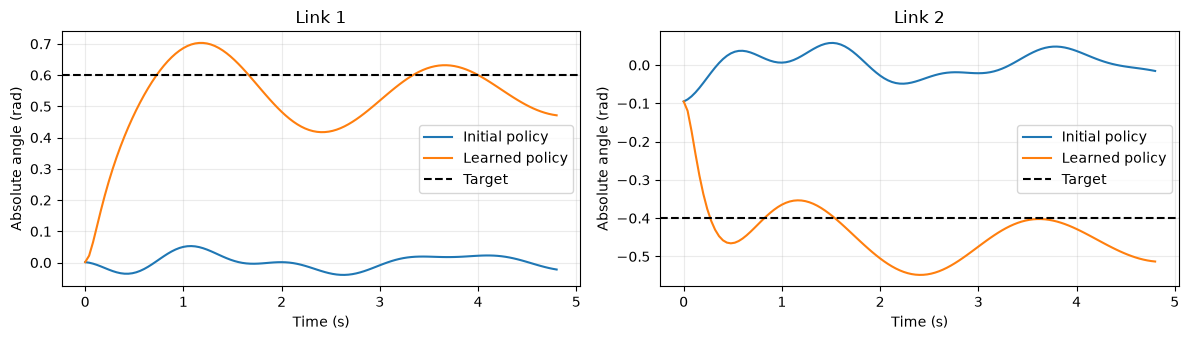

In [7]:
demo_initial, _, _ = rollout(initial_weights, np.random.default_rng(9001), 1, False)
demo_learned, _, _ = rollout(weights, np.random.default_rng(9001), 1, False)
time = np.arange(HORIZON + 1) * DT
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for j, ax in enumerate(axes):
    ax.plot(time, demo_initial[:, 0, j], label="Initial policy")
    ax.plot(time, demo_learned[:, 0, j], label="Learned policy")
    ax.axhline(TARGET[j], color="black", ls="--", label="Target")
    ax.set(xlabel="Time (s)", ylabel="Absolute angle (rad)", title=f"Link {j + 1}")
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
plt.show()


def coordinates(q):
    return np.array([0, np.sin(q[0]), np.sin(q[0]) + np.sin(q[1])]), np.array([
        0, -np.cos(q[0]), -np.cos(q[0]) - np.cos(q[1])])

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
lines = []
for ax, title in zip(axes, ["Initial policy: zero torque", "Learned mean-action policy"]):
    ax.plot(*coordinates(TARGET), "o--", color="gray", alpha=0.6, label="Target")
    line, = ax.plot([], [], "o-", lw=3, markersize=9, label="Pendulum")
    lines.append(line)
    ax.set(xlim=(-2.2, 2.2), ylim=(-2.2, 2.2), title=title, xlabel="x (m)", ylabel="y (m)")
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper right", fontsize=8)
clock_text = fig.suptitle("")
fig.tight_layout()

def animate(frame):
    for line, trajectory in zip(lines, [demo_initial, demo_learned]):
        line.set_data(*coordinates(trajectory[frame, 0, :2]))
    clock_text.set_text(f"Time: {frame * DT:.2f} s")
    return [*lines, clock_text]

animation = FuncAnimation(fig, animate, frames=range(0, HORIZON + 1, 2),
                          interval=2000 * DT, blit=False)
plt.close(fig)  # Avoid displaying a duplicate static figure.
display(HTML(animation.to_jshtml()))  # Self-contained; no ffmpeg needed.


## What to try next

- Change `SEED` and compare complete learning curves: raw Monte Carlo gradients can vary substantially.
- Increase `BATCH_SIZE` to reduce sampling noise, or reduce `LEARNING_RATE` if progress is unstable.
- Remove cross-link features to study the effect of the policy basis.
- Change `TARGET` to a nearby posture, then try a more demanding one. This local regulation example does not demonstrate reliable upright balancing or swing-up.
- Compare larger and smaller `SIGMA`: exploration stays fixed, so stochastic evaluation will usually be worse than mean-action evaluation.

All plotted rewards come from simulation; no reference controller, pretrained weights, or hidden baseline is used.